In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from anndata import AnnData
import glob
import os
import scanpy as sc
from tqdm.notebook import tqdm
from core_functions.processing_and_filtering import *

In [2]:
data_dir = "/mnt/sata3/projects/kbennion/Spatial_Data/output-XETG00195__0043449__TIS09322-001__20250213__230552/xenium_analysis"

In [3]:
input_folders = glob.glob(os.path.join(data_dir, "tumor_1"))


In [27]:
for input_file in tqdm(input_folders):
    # Read the preprocessed .h5ad file from the "adatas" directory
    experiment = sc.read(os.path.join(input_file, "adatas", "01_preprocessed.h5ad"))
    
    # Print the first 10 variable names (genes/features) in the 'var' index
    print(experiment.var.index)
    print("Shape of X:", experiment.X.shape)


  0%|          | 0/1 [00:00<?, ?it/s]

Index(['A1cf', 'A2m', 'Aatf', 'Abca1', 'Abca13', 'Abca3', 'Abca4', 'Abca7',
       'Abca8a', 'Abca8b',
       ...
       'Zp1', 'Zp3', 'Zscan2', 'Zscan21', 'Zswim5', 'Zswim9', 'Zup1', 'Zyx',
       'Zzef1', 'a'],
      dtype='object', length=5105)
Shape of X: (454294, 5105)


  0%|          | 0/1 [00:00<?, ?it/s]

QC metrics for batch tumor_1
quality directory already made


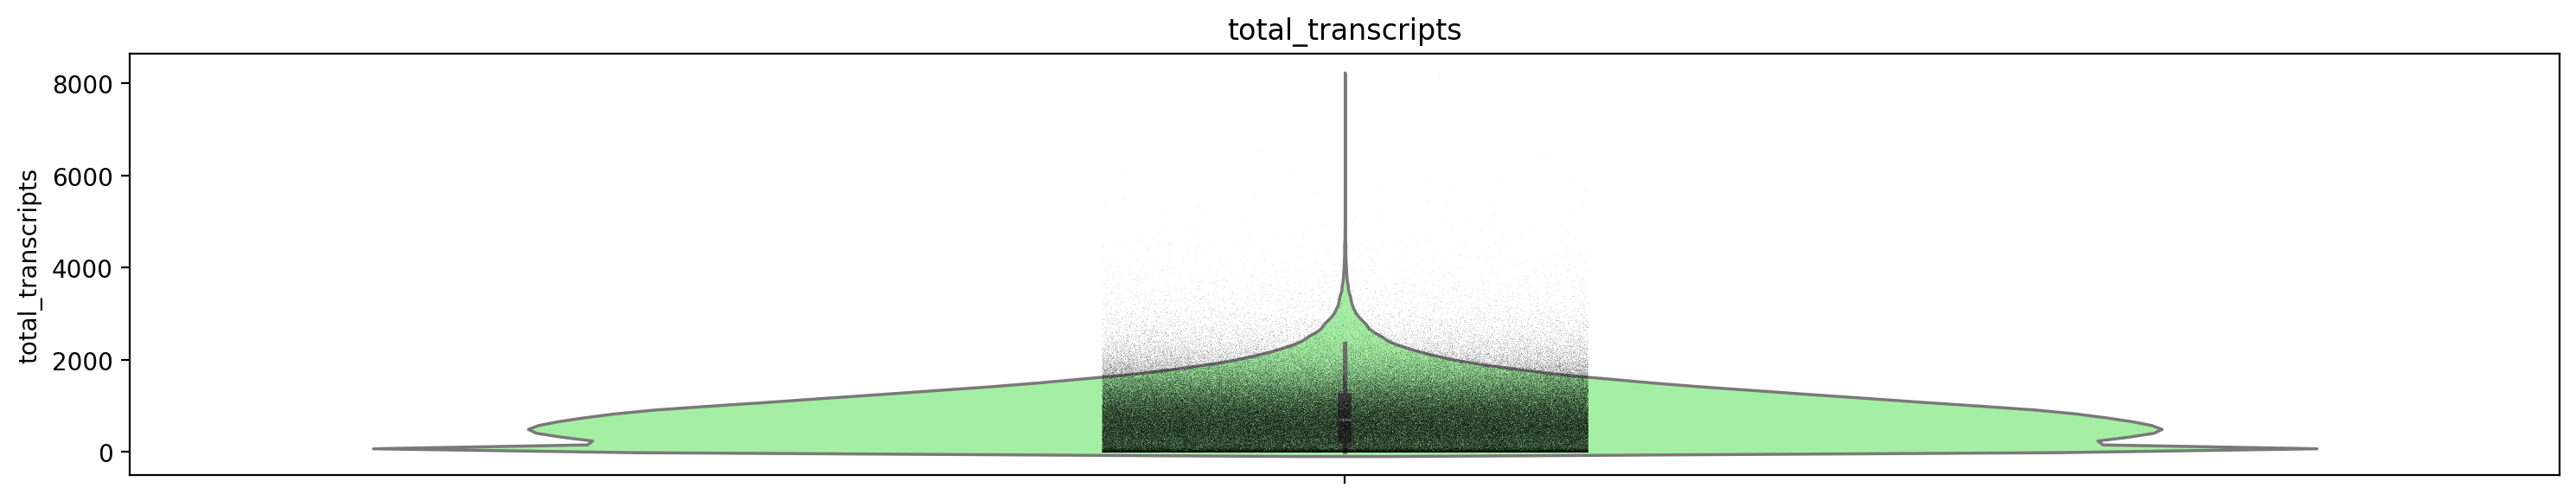

454294 cells before QC filtering
453793 cells after QC filtering


In [4]:
for input_file in tqdm(input_folders):
    experiment = sc.read(os.path.join(input_file, "adatas", "01_preprocessed.h5ad"))
    guides = experiment.var.index.values#[experiment.var.index.str.startswith('Perturbation')]
    try:
        df = pd.DataFrame(
            experiment.X.toarray() if hasattr(experiment.X, "toarray") else experiment.X,
            columns=experiment.var.index.values,
            index=experiment.obs.index.values,
)
    except:
        df = pd.DataFrame(
            experiment.X,
            columns=experiment.var.index.values,
            index=experiment.obs.index.values,
        )
    experiment.obs['total_transcripts'] = experiment.X.sum(axis=1)#.A.sum(axis=1)

    try:
        os.mkdir(os.path.join(input_file, "figures"))
    except:
        pass

    metadata = experiment.obs
    print("QC metrics for batch " + os.path.basename(input_file))

    plot_qc_feature(df, metadata, os.path.join(input_file))



    experiment = qc_before_clustering(experiment, guides=guides)

    experiment.write(
        os.path.join(input_file, "adatas", "02_preprocessed_and_filtered.h5ad")
    )